In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. 기존의 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erro error ; 절대값평균)
- https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![예시](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)  
- 경사하강법 설명
    - https://www.mql5.com/ko/articles/11200
    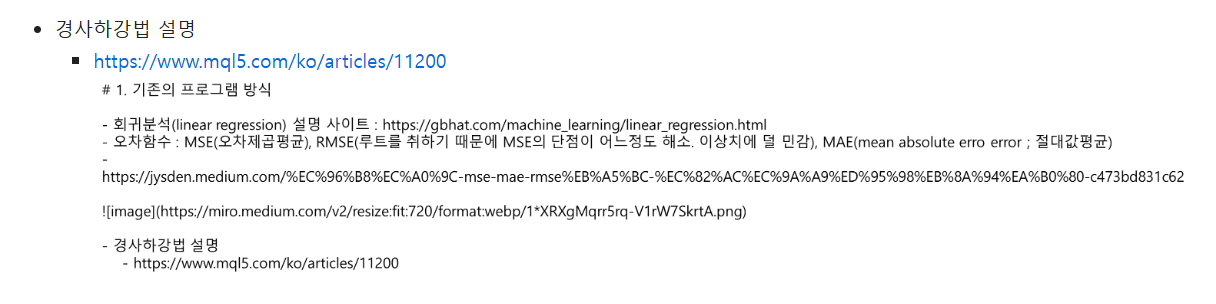
        

In [2]:
# 섭씨온도를 화씨온도를 출력
def celsius_to_faherenheit(c):
    return c * 1.8 + 32

In [3]:
input_c = int(input('섭씨온도 ?'))
print('화씨온도는', celsius_to_faherenheit(input_c))

섭씨온도 ?1
화씨온도는 33.8


# 2. 머신러닝 프로그램 방식
 1. 데이터 확보 및 생성
 2. 데이터 전처리 : 
    스케일 조정
    훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋로 분할
3. 모델구성
4. 모델 학습과정 설정
5. 모델 학습시키기
6. 모델 평가(시험데이터셋으로)
7. 모델 저장 및 사용(입력값이 주어지면 예측값 받기)

## 2.1 노이즈가 없는 데이터로 실습

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 1. 데이터 생성
data_C = np.arange(100) # 0부터 99까지
data_C # 독립변수(입력변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [6]:
data_F = celsius_to_faherenheit(data_C)
data_F # 종속변수(타겟변수, 출력변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [7]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C / 100.0
scaled_data_F = data_F / 100.0
print('학습시 독립변수 :', scaled_data_C)
print('학습시 타겟변수 :', scaled_data_F)

학습시 독립변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
학습시 타겟변수 : [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1

In [8]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

In [13]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정

model = Sequential()
# model.add(Input(shape=(1,) ))
# model.add(Dense(1))
model.add(Dense(units=1, # 타겟(종속) 변수의 갯수
                input_shape=(1,))) #입력(독립)변수의 shape

In [14]:
# 4. 모델 학습과정 설정
model.compile(loss="mse", # 손실함수 - 모델 학습 중 오차를 최소화하기 위해 사용
             optimizer="rmsprop", # 옵티마이저
             metrics=['mae']) #평가지표
# mse : 오차 제곱의 평균
# mae : 오차 절대값의 평균(이상치 영향이 감소)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [16]:
# 학습전 예측
model.predict(np.array([[0],
                       [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 141ms/step


array([[ 0.        ],
       [-0.00772647]], dtype=float32)

In [17]:
# 학습전 모델 저장
model.save('model/before_learning.h5')

In [18]:
# 5. 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, # 입력변수(훈련데이터)
                scaled_data_F, # 타겟변수(훈련데이터)
                epochs=1000, # 학습횟수
                verbose=2) # 학습시 출력여부(0:학습내용출력X)

Epoch 1/1000
4/4 - 0s - loss: 3.0754 - mae: 1.5890 - 373ms/epoch - 93ms/step
Epoch 2/1000
4/4 - 0s - loss: 3.0369 - mae: 1.5780 - 10ms/epoch - 3ms/step
Epoch 3/1000
4/4 - 0s - loss: 3.0095 - mae: 1.5699 - 10ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 2.9839 - mae: 1.5624 - 9ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 2.9618 - mae: 1.5558 - 11ms/epoch - 3ms/step
Epoch 6/1000
4/4 - 0s - loss: 2.9404 - mae: 1.5496 - 12ms/epoch - 3ms/step
Epoch 7/1000
4/4 - 0s - loss: 2.9194 - mae: 1.5434 - 10ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 2.8987 - mae: 1.5372 - 9ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 2.8783 - mae: 1.5312 - 8ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 2.8579 - mae: 1.5251 - 9ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 2.8378 - mae: 1.5190 - 9ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 2.8176 - mae: 1.5129 - 7ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 2.7972 - mae: 1.5067 - 8ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - l

4/4 - 0s - loss: 1.2745 - mae: 0.9519 - 9ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 1.2603 - mae: 0.9458 - 8ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 1.2471 - mae: 0.9401 - 6ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 1.2360 - mae: 0.9351 - 6ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 1.2240 - mae: 0.9300 - 6ms/epoch - 1ms/step
Epoch 115/1000
4/4 - 0s - loss: 1.2120 - mae: 0.9247 - 6ms/epoch - 1ms/step
Epoch 116/1000
4/4 - 0s - loss: 1.2000 - mae: 0.9194 - 6ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.1880 - mae: 0.9143 - 6ms/epoch - 1ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.1761 - mae: 0.9089 - 6ms/epoch - 1ms/step
Epoch 119/1000
4/4 - 0s - loss: 1.1645 - mae: 0.9038 - 6ms/epoch - 1ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.1521 - mae: 0.8983 - 7ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 1.1410 - mae: 0.8933 - 6ms/epoch - 1ms/step
Epoch 122/1000
4/4 - 0s - loss: 1.1315 - mae: 0.8891 - 6ms/epoch - 1ms/step
Epoch 123/1000
4/4 - 0s - l

Epoch 218/1000
4/4 - 0s - loss: 0.3573 - mae: 0.4949 - 6ms/epoch - 1ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.3524 - mae: 0.4919 - 7ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.3473 - mae: 0.4886 - 6ms/epoch - 1ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.3434 - mae: 0.4864 - 6ms/epoch - 1ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.3394 - mae: 0.4837 - 6ms/epoch - 1ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.3349 - mae: 0.4809 - 6ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.3307 - mae: 0.4783 - 6ms/epoch - 1ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.3262 - mae: 0.4755 - 6ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.3216 - mae: 0.4725 - 6ms/epoch - 1ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.3176 - mae: 0.4699 - 6ms/epoch - 1ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.3141 - mae: 0.4677 - 7ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.3098 - mae: 0.4651 - 6ms/epoch - 1ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.3051 - mae: 0.4618 - 6ms/epoch - 1ms/step
Epoch 231/10

Epoch 326/1000
4/4 - 0s - loss: 0.1525 - mae: 0.3379 - 7ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.1519 - mae: 0.3372 - 6ms/epoch - 1ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.1512 - mae: 0.3364 - 6ms/epoch - 1ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.1504 - mae: 0.3357 - 6ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.1496 - mae: 0.3347 - 7ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.1489 - mae: 0.3339 - 7ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.1480 - mae: 0.3329 - 6ms/epoch - 1ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.1473 - mae: 0.3319 - 7ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.1468 - mae: 0.3314 - 6ms/epoch - 1ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.1460 - mae: 0.3305 - 7ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.1454 - mae: 0.3298 - 7ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.1447 - mae: 0.3290 - 8ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.1441 - mae: 0.3282 - 8ms/epoch - 2ms/step
Epoch 339/10

Epoch 434/1000
4/4 - 0s - loss: 0.0825 - mae: 0.2482 - 8ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.0821 - mae: 0.2475 - 6ms/epoch - 1ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.0816 - mae: 0.2468 - 8ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.0810 - mae: 0.2459 - 6ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.0805 - mae: 0.2450 - 7ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.0798 - mae: 0.2440 - 8ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.0792 - mae: 0.2432 - 7ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.0787 - mae: 0.2425 - 8ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.0781 - mae: 0.2415 - 8ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.0777 - mae: 0.2408 - 8ms/epoch - 2ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.0772 - mae: 0.2401 - 6ms/epoch - 1ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.0768 - mae: 0.2393 - 8ms/epoch - 2ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.0762 - mae: 0.2385 - 6ms/epoch - 1ms/step
Epoch 447/10

Epoch 542/1000
4/4 - 0s - loss: 0.0335 - mae: 0.1580 - 8ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.0332 - mae: 0.1574 - 9ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.0329 - mae: 0.1568 - 7ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.0327 - mae: 0.1560 - 7ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.0324 - mae: 0.1554 - 7ms/epoch - 2ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.0322 - mae: 0.1548 - 7ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.0318 - mae: 0.1539 - 7ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.0315 - mae: 0.1532 - 8ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.0312 - mae: 0.1526 - 8ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.0310 - mae: 0.1520 - 6ms/epoch - 1ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.0307 - mae: 0.1513 - 6ms/epoch - 1ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.0303 - mae: 0.1503 - 6ms/epoch - 1ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.0300 - mae: 0.1495 - 6ms/epoch - 1ms/step
Epoch 555/10

Epoch 650/1000
4/4 - 0s - loss: 0.0070 - mae: 0.0721 - 7ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0068 - mae: 0.0715 - 7ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0067 - mae: 0.0707 - 7ms/epoch - 2ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.0065 - mae: 0.0699 - 8ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.0063 - mae: 0.0689 - 6ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.0062 - mae: 0.0681 - 7ms/epoch - 2ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.0061 - mae: 0.0672 - 6ms/epoch - 1ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.0059 - mae: 0.0665 - 6ms/epoch - 1ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.0058 - mae: 0.0655 - 7ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.0056 - mae: 0.0649 - 6ms/epoch - 1ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.0055 - mae: 0.0640 - 7ms/epoch - 2ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.0053 - mae: 0.0632 - 6ms/epoch - 1ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.0052 - mae: 0.0624 - 6ms/epoch - 2ms/step
Epoch 663/10

Epoch 755/1000
4/4 - 0s - loss: 2.5896e-07 - mae: 4.9975e-04 - 6ms/epoch - 1ms/step
Epoch 756/1000
4/4 - 0s - loss: 5.9571e-07 - mae: 7.5432e-04 - 7ms/epoch - 2ms/step
Epoch 757/1000
4/4 - 0s - loss: 8.1611e-07 - mae: 8.8460e-04 - 7ms/epoch - 2ms/step
Epoch 758/1000
4/4 - 0s - loss: 3.5323e-07 - mae: 5.8384e-04 - 7ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 6.7407e-07 - mae: 8.0452e-04 - 7ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 7.0770e-07 - mae: 8.1645e-04 - 6ms/epoch - 1ms/step
Epoch 761/1000
4/4 - 0s - loss: 7.6419e-07 - mae: 8.4401e-04 - 6ms/epoch - 1ms/step
Epoch 762/1000
4/4 - 0s - loss: 2.9663e-07 - mae: 5.2455e-04 - 6ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 2.9436e-07 - mae: 5.2301e-04 - 8ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 1.0394e-06 - mae: 9.9769e-04 - 6ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 6.0300e-07 - mae: 7.4983e-04 - 6ms/epoch - 1ms/step
Epoch 766/1000
4/4 - 0s - loss: 1.0767e-07 - mae: 3.2187e-04 - 7ms/epoch - 2

4/4 - 0s - loss: 6.4804e-07 - mae: 7.8926e-04 - 8ms/epoch - 2ms/step
Epoch 854/1000
4/4 - 0s - loss: 8.7013e-07 - mae: 8.9839e-04 - 11ms/epoch - 3ms/step
Epoch 855/1000
4/4 - 0s - loss: 2.4575e-07 - mae: 4.7742e-04 - 9ms/epoch - 2ms/step
Epoch 856/1000
4/4 - 0s - loss: 3.8166e-07 - mae: 5.9323e-04 - 6ms/epoch - 1ms/step
Epoch 857/1000
4/4 - 0s - loss: 1.1120e-06 - mae: 0.0010 - 8ms/epoch - 2ms/step
Epoch 858/1000
4/4 - 0s - loss: 3.7797e-07 - mae: 5.9610e-04 - 6ms/epoch - 1ms/step
Epoch 859/1000
4/4 - 0s - loss: 4.6671e-07 - mae: 6.6269e-04 - 8ms/epoch - 2ms/step
Epoch 860/1000
4/4 - 0s - loss: 4.7464e-07 - mae: 6.7649e-04 - 6ms/epoch - 1ms/step
Epoch 861/1000
4/4 - 0s - loss: 6.0540e-07 - mae: 7.6324e-04 - 7ms/epoch - 2ms/step
Epoch 862/1000
4/4 - 0s - loss: 3.7925e-07 - mae: 5.9808e-04 - 6ms/epoch - 1ms/step
Epoch 863/1000
4/4 - 0s - loss: 8.5167e-07 - mae: 9.0681e-04 - 7ms/epoch - 2ms/step
Epoch 864/1000
4/4 - 0s - loss: 8.0633e-07 - mae: 8.5062e-04 - 7ms/epoch - 2ms/step
Epoch 865/

Epoch 952/1000
4/4 - 0s - loss: 1.1399e-06 - mae: 9.6316e-04 - 6ms/epoch - 1ms/step
Epoch 953/1000
4/4 - 0s - loss: 5.9146e-09 - mae: 6.2208e-05 - 6ms/epoch - 1ms/step
Epoch 954/1000
4/4 - 0s - loss: 1.2388e-08 - mae: 1.0044e-04 - 6ms/epoch - 2ms/step
Epoch 955/1000
4/4 - 0s - loss: 1.9274e-07 - mae: 3.8374e-04 - 5ms/epoch - 1ms/step
Epoch 956/1000
4/4 - 0s - loss: 2.0007e-06 - mae: 0.0014 - 6ms/epoch - 2ms/step
Epoch 957/1000
4/4 - 0s - loss: 2.0328e-07 - mae: 4.2963e-04 - 6ms/epoch - 1ms/step
Epoch 958/1000
4/4 - 0s - loss: 1.4734e-07 - mae: 3.7422e-04 - 6ms/epoch - 1ms/step
Epoch 959/1000
4/4 - 0s - loss: 8.4287e-07 - mae: 8.8695e-04 - 5ms/epoch - 1ms/step
Epoch 960/1000
4/4 - 0s - loss: 1.0042e-06 - mae: 9.5336e-04 - 6ms/epoch - 1ms/step
Epoch 961/1000
4/4 - 0s - loss: 2.9310e-07 - mae: 5.2619e-04 - 7ms/epoch - 2ms/step
Epoch 962/1000
4/4 - 0s - loss: 1.3757e-07 - mae: 3.5437e-04 - 6ms/epoch - 1ms/step
Epoch 963/1000
4/4 - 0s - loss: 9.6281e-07 - mae: 9.4536e-04 - 6ms/epoch - 1ms/s

In [19]:
# 6. 모델 평가(그래프를 통해 loss와 metrics값의 추이, 평가함수)
print(hist.history.keys())
print(hist.history['loss'][:5])
print(hist.history['mae'][:5])

dict_keys(['loss', 'mae'])
[3.075446367263794, 3.0368824005126953, 3.0095083713531494, 2.983870267868042, 2.9618215560913086]
[1.5890141725540161, 1.5780143737792969, 1.5699255466461182, 1.5624372959136963, 1.555777907371521]


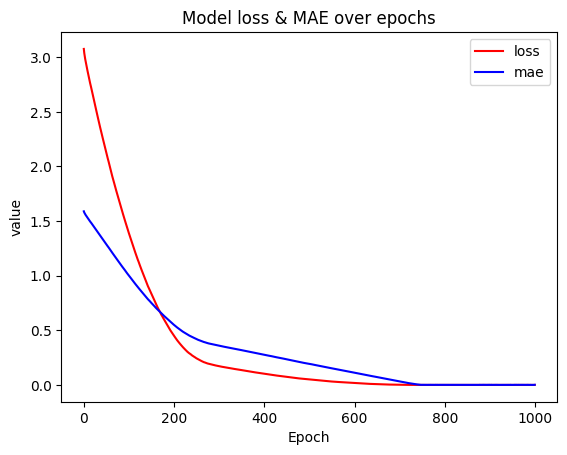

In [20]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend() # 범례 label 추가
plt.xlabel('Epoch')
plt.ylabel('value')
plt.title('Model loss & MAE over epochs')
plt.show()

In [21]:
# 7. 모델 저장 및 사용
# 학습 후 예측
model.predict(np.array([[0],
                       [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?


1/1 [==============================] - 0s 23ms/step


array([[0.31980133],
       [0.33779824]], dtype=float32)

In [22]:
model.save('model/after_learning.h5')

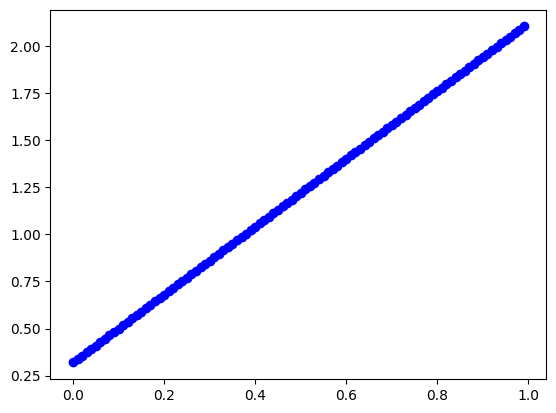

In [24]:
# 실제값
plt.scatter(x=scaled_data_C,
           y=scaled_data_F,
           c='b')
plt.show()

In [25]:
# 예측값
y_hat = model.predict([scaled_data_C])
for h, y in zip(y_hat, scaled_data_F):
    print('예측값:{}, 실제값:{}, 오차:{}'.format(h,
                                      y,
                                      h[0]-y))

4/4 [==============================] - 0s 2ms/step
예측값:[0.31980133], 실제값:0.32, 오차:-0.00019866943359375666
예측값:[0.33779824], 실제값:0.33799999999999997, 오차:-0.0002017621994018226
예측값:[0.35579515], 실제값:0.35600000000000004, 오차:-0.00020485496520999957
예측값:[0.37379205], 실제값:0.374, 오차:-0.00020794773101806552
예측값:[0.39178896], 실제값:0.392, 오차:-0.00021104049682618697
예측값:[0.4097859], 실제값:0.41, 오차:-0.00021410346031186522
예측값:[0.4277828], 실제값:0.428, 오차:-0.00021719622611998668
예측값:[0.4457797], 실제값:0.446, 오차:-0.00022028899192810814
예측값:[0.46377662], 실제값:0.46399999999999997, 오차:-0.00022338175773617408
예측값:[0.48177356], 실제값:0.48200000000000004, 오차:-0.00022644472122196335
예측값:[0.49977046], 실제값:0.5, 오차:-0.0002295374870300293
예측값:[0.51776737], 실제값:0.518, 오차:-0.00023263025283815075
예측값:[0.5357643], 실제값:0.536, 오차:-0.0002357230186462722
예측값:[0.5537612], 실제값:0.554, 오차:-0.00023881578445439366
예측값:[0.5717581], 실제값:0.5720000000000001, 오차:-0.00024190855026251512
예측값:[0.58975506], 실제값:0.59, 오차:-0.0002449417114257501

In [ ]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', alpha=0.5) # 투명

## 2.2 노이즈가 있는 데이터로 실습

In [29]:
np.random.seed(7)
noise = np.random.normal(0, scale=0.1, size=100) # 평균 0, 표준편차 0.1개 100개 데이터
noised_scaled_data_F = scaled_data_F + noise

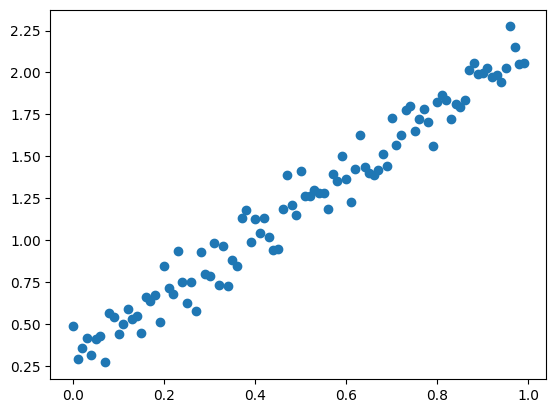

In [30]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [31]:
# 3. 모델구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [32]:
# 5. 모델 학습
hist2 = model2.fit(scaled_data_C, noised_scaled_data_F, epochs=1000, verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6923 - mae: 0.7775
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.6738 - mae: 0.7661
Epoch 3/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6615 - mae: 0.7586
Epoch 4/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.6497 - mae: 0.7513
Epoch 5/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6388 - mae: 0.7445
Epoch 6/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6291 - mae: 0.7384
Epoch 7/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6192 - mae: 0.7321
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6100 - mae: 0.7262
Epoch 9/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.6003 - mae: 0.7200
Epoch 10/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.5918 - mae: 0.7144
Epoch 11/1000
4/4 [==============================] - 0s 3ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 0.0205 - mae: 0.1175
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0203 - mae: 0.1171
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0201 - mae: 0.1164
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0199 - mae: 0.1158
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0197 - mae: 0.1153
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0195 - mae: 0.1149
Epoch 180/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0193 - mae: 0.1141
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0192 - mae: 0.1137
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0190 - mae: 0.1132
Epoch 183/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0189 - mae: 0.1127
Epoch 184/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0808
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0805
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0805
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0806
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0806
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0801
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0803
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0802
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0802
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0803
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 519/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0803
Epoch 520/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 521/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 522/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 523/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 524/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 525/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 526/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 527/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 528/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 691/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0806
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0804
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0803
Epoch 698/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0803
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0805
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0103 - mae: 0.0812
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0104 - mae: 0.0814
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0810
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0810
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0811
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0809
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0807
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0103 - mae: 0.0808
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

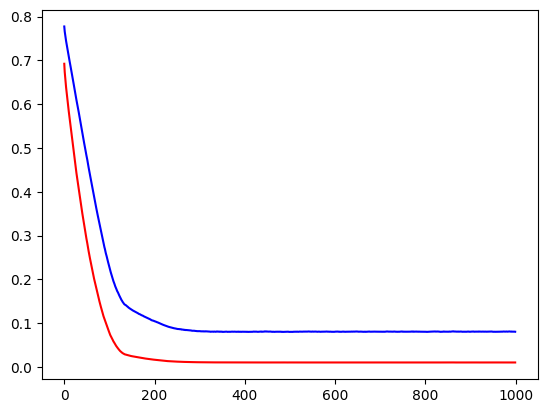

In [33]:
# 6. 학습된 모델 과정 살펴보기
plt.plot(hist2.history['loss'], c='r')
plt.plot(hist2.history['mae'], c='b')

In [34]:
model.save('model/noise_after_learning.h5')

In [35]:
# 예측값
y_hat = model2.predict([scaled_data_C])

4/4 [==============================] - 0s 2ms/step


In [39]:
for h, y in zip(y_hat, noised_scaled_data_F):
    print("실제값:{}, 예측값:{}, 오차:{}". format(y,
                                        h,
                                        h[0]-y))

실제값:0.48905257038003563, 예측값:[0.30237666], 오차:-0.18667591265565514
실제값:0.2914062629459167, 예측값:[0.32072908], 오차:0.0293228139164185
실제값:0.3592820163678585, 예측값:[0.33908147], 오차:-0.020200550169890974
실제값:0.4147516282996508, 예측값:[0.3574339], 오차:-0.057317742963728546
실제값:0.31310769713742614, 예측값:[0.37578627], 오차:0.06267857753412842
실제값:0.4102065572905948, 예측값:[0.3941387], 오차:-0.01606786348108552
실제값:0.42791096141420687, 예측값:[0.41249108], 오차:-0.015419878269065268
실제값:0.2705275693654579, 예측값:[0.4308435], 오차:0.1603159329176384
실제값:0.5657658005663493, 예측값:[0.44919592], 오차:-0.11656987914529826
실제값:0.542049851591955, 예측값:[0.4675483], 오차:-0.0745015408352716
실제값:0.43745710260332404, 예측값:[0.4859007], 오차:0.04844359748899163
실제값:0.5008451738804279, 예측값:[0.50425315], 오차:0.003407975152164844
실제값:0.5865299374196752, 예측값:[0.52260554], 오차:-0.06392439905145009
실제값:0.5278643584808353, 예측값:[0.5409579], 오차:0.013093569223022072
실제값:0.5477250921327455, 예측값:[0.5593103], 오차:0.011585224906744296
실제값:0.444675858750

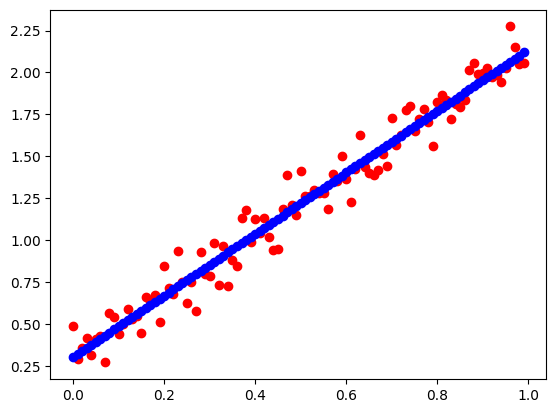

In [37]:
plt.scatter(x=scaled_data_C,
           y=noised_scaled_data_F,
           c='r')
plt.scatter(x=scaled_data_C,
           y=y_hat,
           c='b')